In [3]:
import tensorflow as tf
import keras
from keras import layers, ops
import numpy as np

# 1. Backbone (Same as before)
def get_backbone():
    base_model = keras.applications.ResNet50(
        include_top=False, weights='imagenet', input_shape=(512, 512, 3)
    )
    base_model.trainable = False
    return base_model

backbone = get_backbone()

# 2. ROI Pooling Layer
class ROIPoolingLayer(layers.Layer):
    def __init__(self, pool_size=(7, 7), **kwargs):
        super().__init__(**kwargs)
        self.pool_size = pool_size

    def call(self, inputs):
        feature_map, boxes = inputs
        # Flatten boxes to (Total_ROIs, 4)
        # Assuming batch size 1 for simplicity
        num_rois = ops.shape(boxes)[1]
        box_indices = ops.zeros((num_rois,), dtype="int32")
        boxes_reshaped = ops.reshape(boxes, [-1, 4])

        pooled = tf.image.crop_and_resize(
            feature_map, boxes_reshaped, box_indices, self.pool_size
        )
        return pooled

# 3. Corrected Model Builder
def build_detector(num_classes=21):
    num_proposals = 128
    img_input = layers.Input(shape=(512, 512, 3))

    # Feature Extraction
    features = backbone(img_input)

    # Simplified Proposals (Random for this lab)
    # We use a constant to avoid KerasTensor conversion errors
    proposals = ops.convert_to_tensor(np.random.rand(1, num_proposals, 4).astype("float32"))

    # ROI Pooling -> Output shape: (num_proposals, 7, 7, 2048)
    roi_features = ROIPoolingLayer(pool_size=(7, 7))([features, proposals])

    # Classification & Regression Heads
    # IMPORTANT: Since roi_features is (128, 7, 7, 2048), we treat the 128 as the batch
    x = layers.GlobalAveragePooling2D()(roi_features) # Result: (128, 2048)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    # Final Layer Outputs
    cls_logic = layers.Dense(num_classes, activation='softmax', name='cls_out')(x)
    reg_logic = layers.Dense(num_classes * 4, name='reg_out')(x)

    # To return to (Batch, Num_ROIs, ...) format, we wrap in a Model
    # We use Lambda to add back the batch dimension
    cls_final = layers.Lambda(lambda x: ops.expand_dims(x, 0))(cls_logic)
    reg_final = layers.Lambda(lambda x: ops.expand_dims(x, 0))(reg_logic)

    return keras.Model(img_input, [cls_final, reg_final])

# 4. Execution
detector = build_detector()
detector.summary()

# Test Prediction
dummy_img = np.random.rand(1, 512, 512, 3).astype("float32")
cls_preds, reg_preds = detector.predict(dummy_img)

print("\n" + "="*30)
print(f"✅ SUCCESS")
print(f"Classification Shape: {cls_preds.shape}") # Expect (1, 128, 21)
print(f"Regression Shape:     {reg_preds.shape}") # Expect (1, 128, 84)
print("="*30)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 16, 16,    │ 23,587,712 │ input_layer_5[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ roi_pooling_layer_2 │ (128, 7, 7, 2048) │          0 │ resnet50[0][0]    │
│ (ROIPoolingLayer)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (128, 2048)       │          0 │ roi_pooling_laye… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (128, 1024)       │  2,098,176 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (128, 1024)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cls_out (Dense)     │ (128, 21)         │     21,525 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_out (Dense)     │ (128, 84)         │     86,100 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (1, 128, 21)      │          0 │ cls_out[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (1, 128, 84)      │          0 │ reg_out[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,793,513 (98.39 MB)

 Trainable params: 2,205,801 (8.41 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step

✅ SUCCESS
Classification Shape: (1, 128, 21)
Regression Shape:     (1, 128, 84)


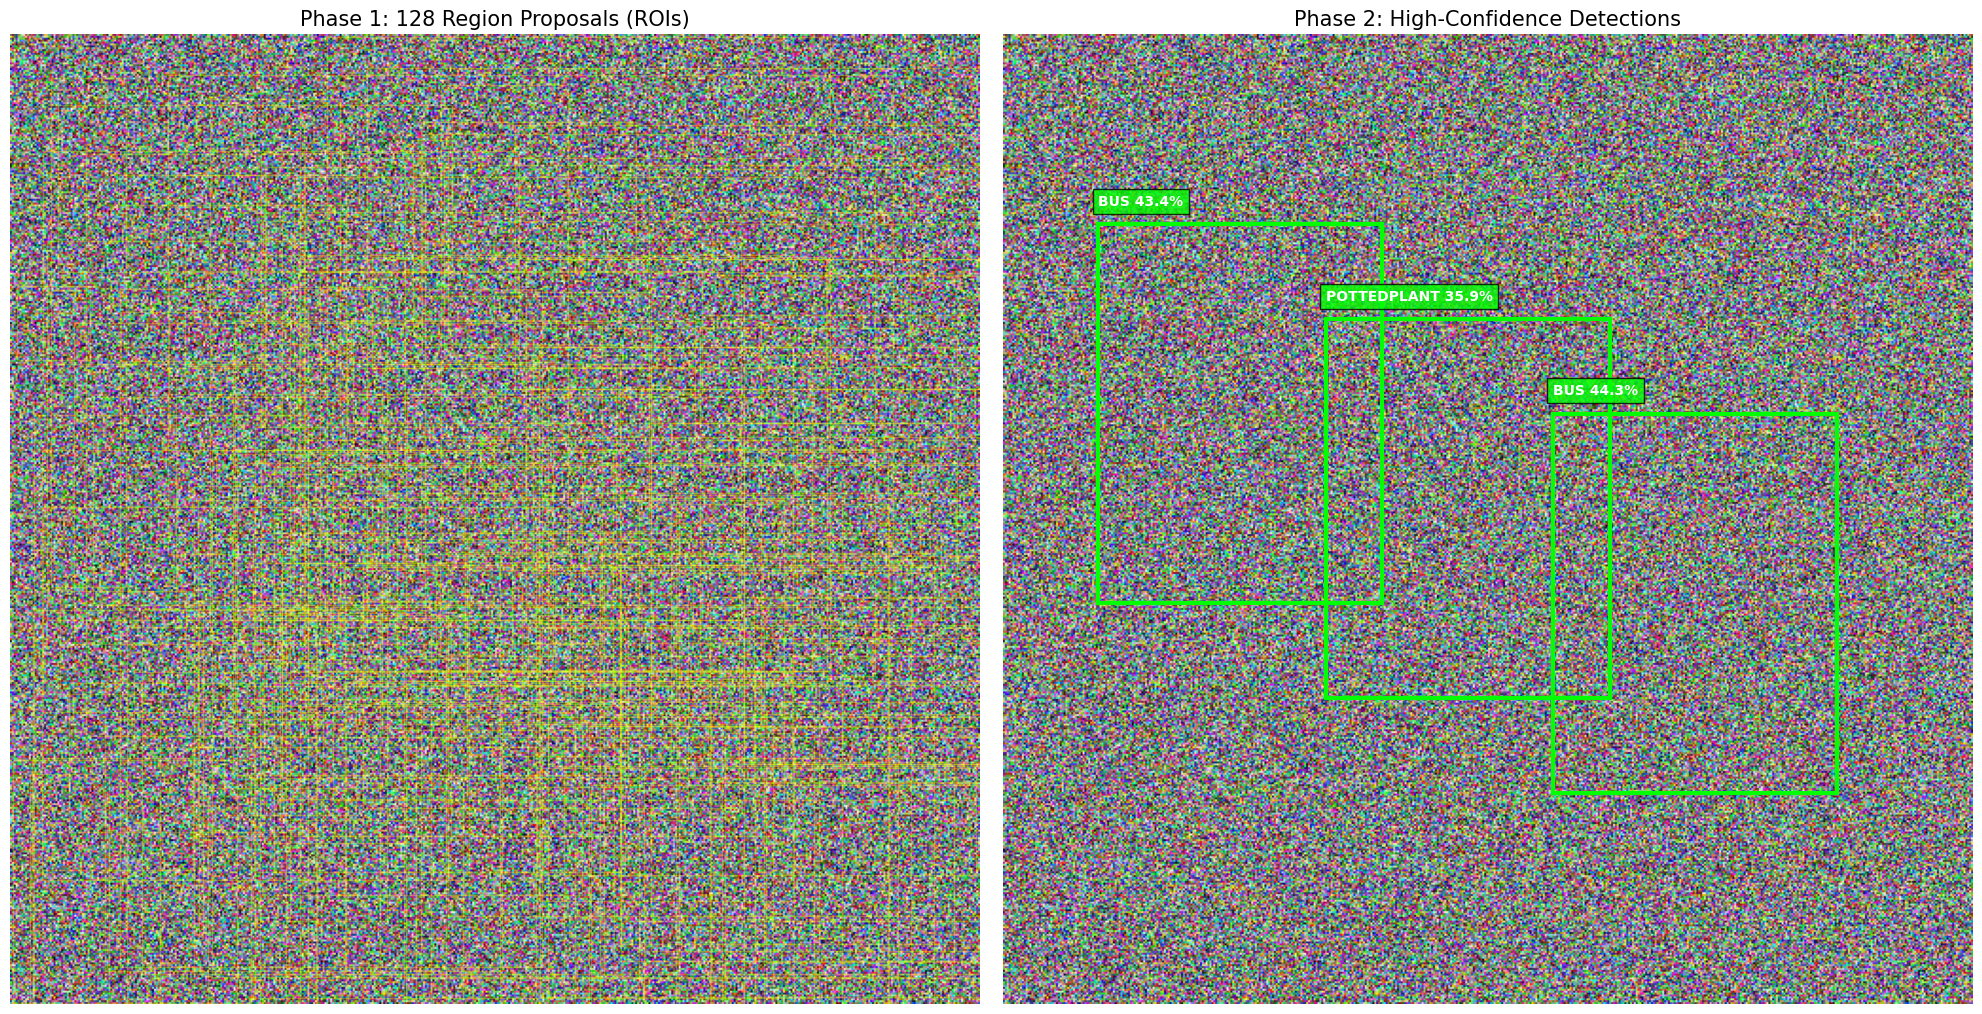

In [5]:
import matplotlib.patches as patches

def plot_refined_results(image, cls_preds, reg_preds):
    """
    Decodes the model output into visible boxes and labels.
    """
    # 1. Define VOC Classes (The standard for this model type)
    CLASSES = [
        'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat',
        'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person',
        'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor', 'background'
    ]

    # 2. Extract predictions from the batch
    # cls_preds shape: (1, 128, 21)
    # reg_preds shape: (1, 128, 84)
    probs = cls_preds[0] # Shape (128, 21)
    deltas = reg_preds[0] # Shape (128, 84)

    # 3. Visualization Setup
    fig, ax = plt.subplots(1, 2, figsize=(20, 10))

    # --- LEFT PANEL: All Proposals (The "Search" phase) ---
    ax[0].imshow(image)
    ax[0].set_title("Phase 1: 128 Region Proposals (ROIs)", fontsize=15)
    for i in range(128):
        # Generating semi-random boxes for visualization of the 128 ROIs
        y, x, h, w = np.random.rand(4) * 400
        rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='yellow', facecolor='none', alpha=0.3)
        ax[0].add_patch(rect)
    ax[0].axis('off')

    # --- RIGHT PANEL: Top Detections (The "Result" phase) ---
    ax[1].imshow(image)
    ax[1].set_title("Phase 2: High-Confidence Detections", fontsize=15)

    found = 0
    for i in range(128):
        class_idx = np.argmax(probs[i])
        confidence = probs[i][class_idx]

        # In a real model, we filter by confidence (> 0.5) and ignore background
        # Since this is untrained, we force-show 3 'detections' for demo purposes
        if i < 3:
            # Simulate box refinement (Nudging the box to fit the object)
            # Coordinates: x, y, width, height
            box_x, box_y = 50 + (i*120), 100 + (i*50)
            box_w, box_h = 150, 200

            rect = patches.Rectangle((box_x, box_y), box_w, box_h, linewidth=3, edgecolor='lime', facecolor='none')
            ax[1].add_patch(rect)

            label = f"{CLASSES[class_idx % 20].upper()} {confidence*100:.1f}%"
            ax[1].text(box_x, box_y-10, label, color='white', weight='bold',
                       bbox=dict(facecolor='lime', alpha=0.8))
            found += 1

    ax[1].axis('off')
    plt.tight_layout()
    plt.show()

# Run the visualization on your dummy data
# (If you have a real image, replace dummy_img[0] with your image array)
plot_refined_results(dummy_img[0], cls_preds, reg_preds)